In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv("superstore_level2.csv")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.00,41.9136
1,2,CA-2016-152156,11/08/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3.0,0.00,219.5820
2,3,CA-2016-138688,06/12/16,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,NaN,FUR-TA-10000577,NaN,Tables,Bretford CR4500 Series Slim Rectangular Table,NaN,NaN,0.45,NaN
4,5,US-2015-108966,10/11/15,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.20,2.5164


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10494 non-null  int64  
 1   Order ID       10494 non-null  object 
 2   Order Date     10494 non-null  object 
 3   Ship Date      10493 non-null  object 
 4   Ship Mode      10492 non-null  object 
 5   Customer ID    10491 non-null  object 
 6   Customer Name  10491 non-null  object 
 7   Segment        10490 non-null  object 
 8   Country        10494 non-null  object 
 9   City           10493 non-null  object 
 10  State          10488 non-null  object 
 11  Postal Code    10493 non-null  float64
 12  Region         10176 non-null  object 
 13  Product ID     10494 non-null  object 
 14  Category       10174 non-null  object 
 15  Sub-Category   10492 non-null  object 
 16  Product Name   10494 non-null  object 
 17  Sales          10179 non-null  float64
 18  Quanti

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,10494.000000,10493.000000,10179.000000,10177.000000,10492.000000,10178.000000
mean,4994.578045,55150.785095,229.118802,3.787462,0.156031,28.384907
std,2890.773929,32024.289892,620.413693,2.214280,0.206454,232.244110
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2490.250000,23223.000000,17.264000,2.000000,0.000000,1.728000
50%,4991.500000,55901.000000,54.384000,3.000000,0.200000,8.694000
75%,7497.750000,90008.000000,208.300000,5.000000,0.200000,29.338000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          1
Ship Mode          2
Customer ID        3
Customer Name      3
Segment            4
Country            0
City               1
State              6
Postal Code        1
Region           318
Product ID         0
Category         320
Sub-Category       2
Product Name       0
Sales            315
Quantity         317
Discount           2
Profit           316
dtype: int64

In [11]:
df.duplicated().sum()

440

In [12]:
df = df.drop_duplicates()

In [16]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(0)

In [17]:
df = df.dropna()

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

In [20]:
df['Category'] = df['Category'].str.strip()
df['Region'] = df['Region'].str.strip()

In [21]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_states)

State
California      444808.1335
New York        298716.2970
Texas           164729.4530
Washington      138223.6020
Pennsylvania    112715.8530
Name: Sales, dtype: float64


In [22]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         140857.8170
Office Supplies    118302.1351
Furniture           18875.0252
Name: Profit, dtype: float64


In [23]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       711091.6685
East       656967.2970
Central    484336.6780
South      377039.2945
Name: Sales, dtype: float64


In [24]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2014-01     14195.6910
2014-02      4486.6160
2014-03     55583.1730
2014-04     28047.9610
2014-05     23515.7110
2014-06     33947.2876
2014-07     33573.2330
2014-08     26419.2725
2014-09     79054.3828
2014-10     30880.8430
2014-11     71527.5387
2014-12     67908.5625
2015-01     13858.9516
2015-02     11730.2910
2015-03     38690.4890
2015-04     32136.7425
2015-05     29792.7425
2015-06     24448.3980
2015-07     26679.3690
2015-08     35757.4642
2015-09     64443.1160
2015-10     30128.9875
2015-11     73931.5080
2015-12     71586.8092
2016-01     18007.7610
2016-02     22012.5250
2016-03     50744.3750
2016-04     38661.5090
2016-05     52727.5060
2016-06     40169.0420
2016-07     37864.8840
2016-08     31006.7983
2016-09     69839.2049
2016-10     59259.4570
2016-11     77669.2558
2016-12     94380.6590
2017-01     43576.2280
2017-02     19910.5374
2017-03     57317.2368
2017-04     35818.2401
2017-05     41896.8242
2017-06     50740.6337
2017-07     45204.7360
2017-

In [25]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(sub_profit.head())

Sub-Category
Copiers        55367.8299
Phones         43547.2268
Accessories    40196.4051
Paper          32379.9541
Binders        29397.9073
Name: Profit, dtype: float64


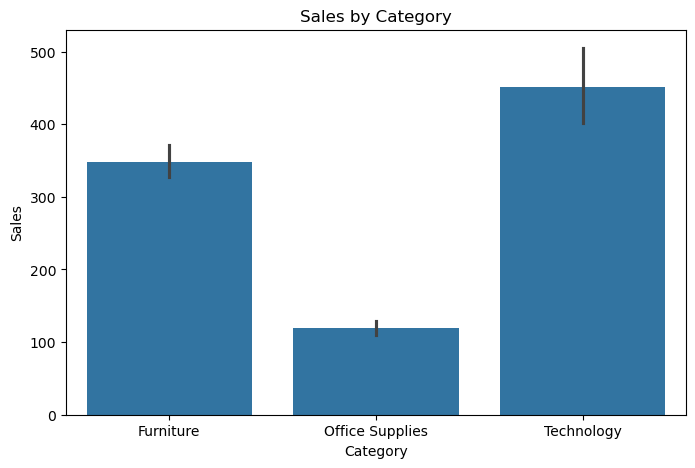

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

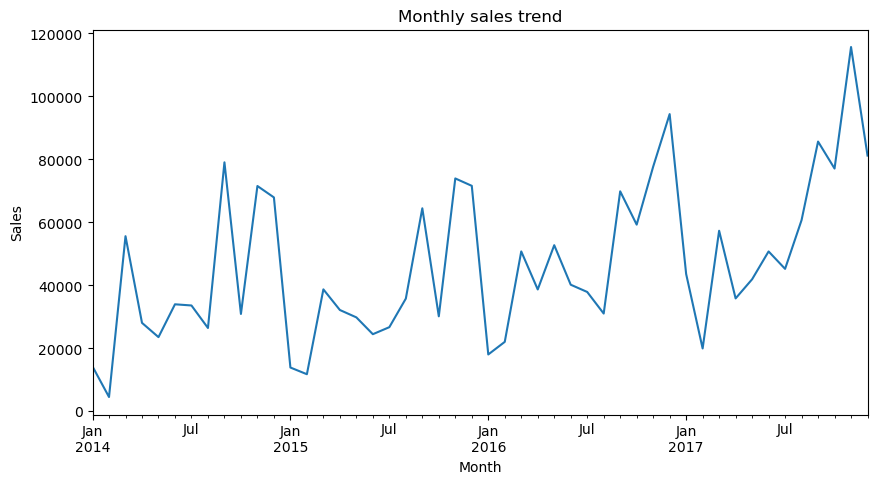

In [30]:
monthly_sales.plot(kind='line',figsize=(10,5))
plt.title("Monthly sales trend")
plt.ylabel("Sales")
plt.show()

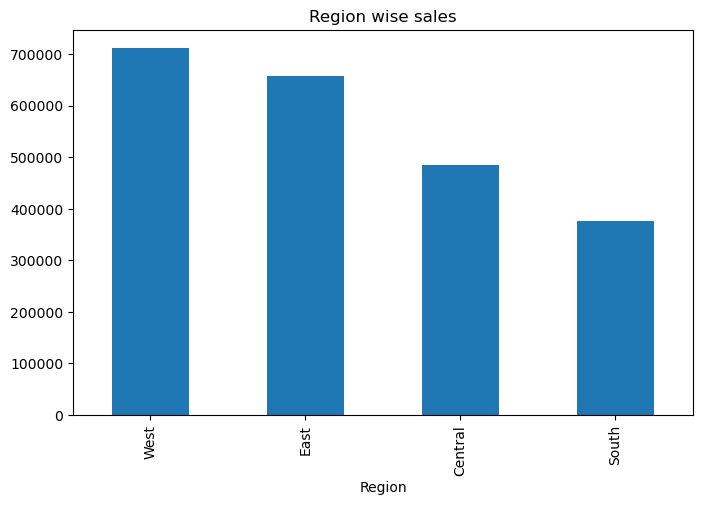

In [32]:
region_sales.plot(kind='bar',figsize=(8,5))
plt.title("Region wise sales")
plt.show()

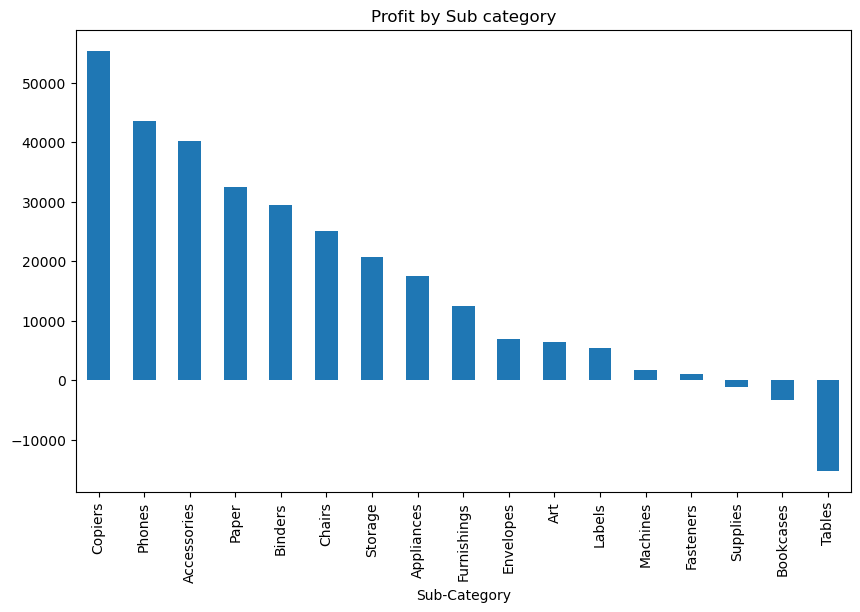

In [33]:
top_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
top_sub.plot(kind='bar')
plt.title("Profit by Sub category")
plt.show()

In [34]:
country_profit = df.groupby('Country')['Profit'].sum().sort_values(ascending=False)
print(country_profit)

Country
United States    278034.9773
Name: Profit, dtype: float64


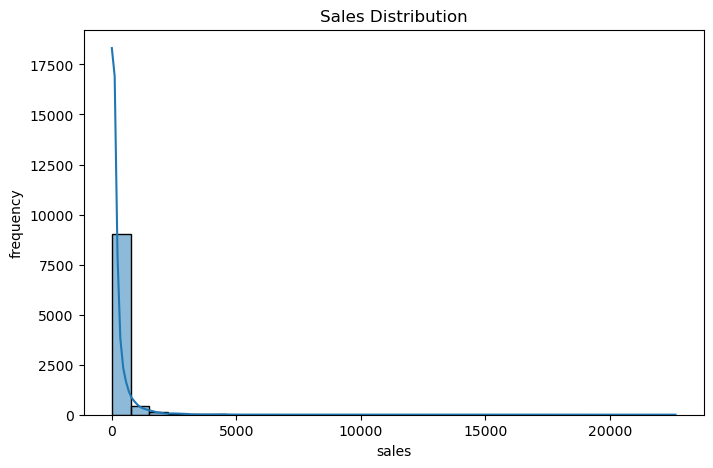

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("sales")
plt.ylabel("frequency")
plt.show()

In [37]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(1)

City
New York City    244988.977
Name: Sales, dtype: float64

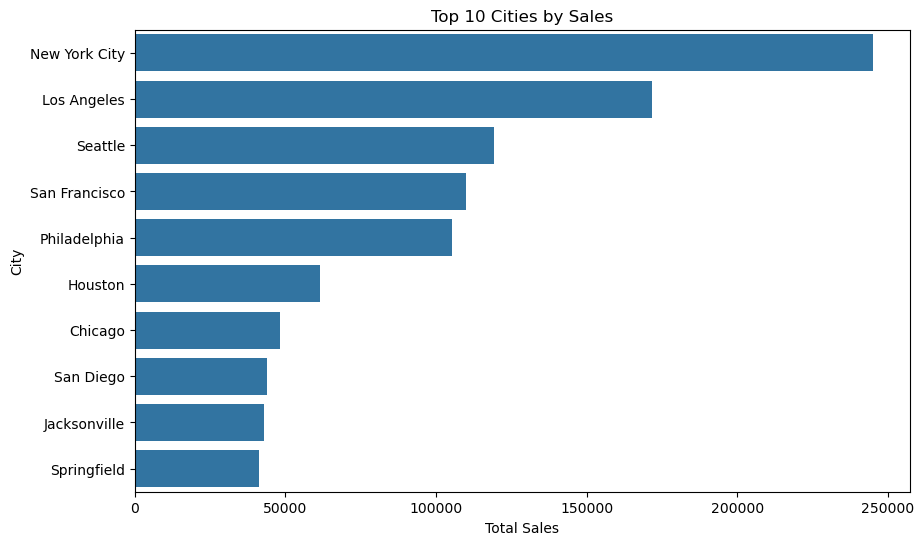

In [38]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

top_cities = city_sales.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

## Key Insights from the Dataset

### **1. Top Performing State**
- The **top 5 states** contribute a significant portion of the **total sales**.
- This indicates that a small number of states dominate the **overall market demand**.

---

### **2. Highest Sales City**
- The **city with the highest total purchases** generates the **maximum sales revenue**.
- This suggests that cities with a **larger customer base** contribute more to total sales.

---

### **3. Most Profitable Category**
- The **most profitable product category** plays a crucial role in the **company’s overall profitability**.
- Prioritizing this category in **marketing and inventory planning** could further increase profits.

---

### **4. Regional Performance**
- One **region records the highest total revenue** compared to other regions.
- This indicates **stronger demand and better sales performance** in that region.

---

### **5. Monthly Sales Trend**
- Sales show **noticeable fluctuations across different months**.
- Certain months experience **higher sales**, possibly due to **seasonal demand or promotional campaigns**.

---

### **6. Most Profitable Sub-Category**
- A specific **sub-category generates the highest profit**.
- This suggests that these products are **highly successful in terms of demand and pricing strategy**.